# Machine Learning with Environmental Text Data

This notebook focuses on supervised learning techniques for text classification, using environmental text data to predict document labels, stances, or outcomes.

## Learning Objectives:
- Use labeled environmental text for supervised classification tasks
- Extract features using bag-of-words and TF-IDF approaches
- Fit classification models: logistic regression and naïve Bayes
- Evaluate model performance using confusion matrices and AUC scores
- Understand the machine learning pipeline for text data

Let's get started by loading the necessary packages!


In [18]:
# Load the required packages
library(tidyverse)     # Data manipulation and visualization
library(tidytext)      # Text mining with tidy data principles
library(tm)            # Text mining utilities
library(ggplot2)       # Data visualization
library(dplyr)         # Data manipulation
library(stringr)       # String manipulation
library(knitr)         # For nice table output
library(scales)        # For better plot scales
library(caret)         # Machine learning framework
library(e1071)         # Naive Bayes classifier
library(randomForest)  # Random Forest (bonus)
library(glmnet)        # Regularized regression
library(Matrix)        # Sparse matrices


## Part 1: Data Preparation and Exploration

### Understanding Our Classification Task

**What is Document Classification?**

Document classification is like teaching a computer to sort emails into different folders automatically. Instead of a human reading each email and deciding whether it goes in "Work," "Personal," or "Spam," we train a computer algorithm to make these decisions based on patterns it learns from the text.

In our case, we'll use the climate topics dataset to predict document labels. This is a **multi-class classification** problem where we want to predict which of the 5 topic categories (0-4) each document belongs to based on its text content.

**How Does Machine Learning Work for Text?**

Think of it this way:
1. **Training Phase**: We show the computer many examples of documents that have already been labeled by humans (like showing a child many pictures of cats labeled "cat" and dogs labeled "dog")
2. **Learning Phase**: The computer finds patterns in the text that help distinguish between different categories (like learning that documents about politics often contain words like "policy," "government," or "legislation")
3. **Prediction Phase**: When given a new, unlabeled document, the computer uses these learned patterns to guess which category it belongs to

**Why is This Useful?**

This type of task is common in environmental research for:
- **Stance Detection**: Automatically classifying whether news articles, social media posts, or policy documents support or oppose climate policies (instead of reading thousands of documents manually)
- **Content Classification**: Sorting large collections of environmental documents by theme (ocean science, agriculture, policy, etc.) to help researchers find relevant information quickly
- **Outcome Prediction**: Analyzing the language in policy proposals to predict whether they're likely to be successful

**The Machine Learning Pipeline**

Our process will follow these key steps:
1. **Data Preparation**: Clean and organize our text data
2. **Feature Extraction**: Convert text into numbers that algorithms can understand
3. **Model Training**: Teach algorithms to recognize patterns
4. **Evaluation**: Test how well our trained models perform on new data

Don't worry if this seems complex - we'll walk through each step together!


Rows: 2633 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): text
dbl (1): label

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Total documents: 2633 
Class distribution:



   General climate discussion           Politics and policy 
                         1499                           713 
                  Ocean/Water          Agriculture/forestry 
                          157                           135 
Climate disasters and impacts 
                          129 

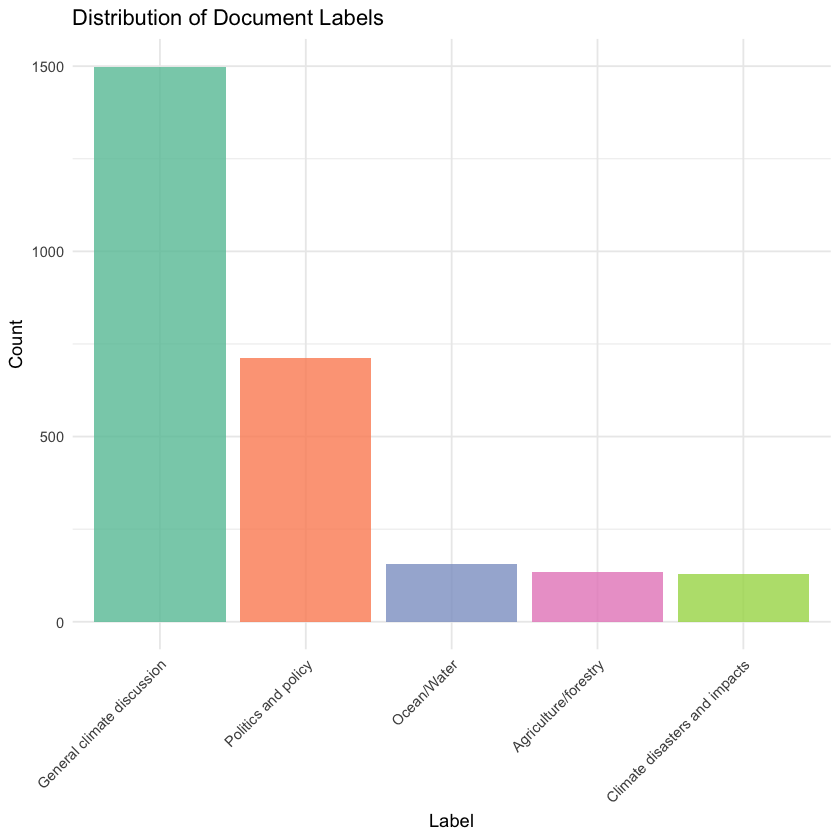

In [19]:
# Load the climate topics dataset
climate_data <- read_csv("data/climate_data_course.csv")

# Convert labels to factor with descriptive levels
climate_data$label <- factor(climate_data$label, 
                            levels = 0:4,
                            labels = c("General climate discussion",
                                     "Politics and policy", 
                                     "Ocean/Water",
                                     "Agriculture/forestry",
                                     "Climate disasters and impacts"))

# Clean the text data
climate_clean <- climate_data %>%
  # Remove rows with missing text
  filter(!is.na(text)) %>%
  # Convert to lowercase
  mutate(text = tolower(text)) %>%
  # Remove URLs (simple pattern)
  mutate(text = str_replace_all(text, "https?://\\S+", "")) %>%
  # Remove Twitter handles
  mutate(text = str_replace_all(text, "@\\w+", "")) %>%
  # Remove hashtags but keep the words
  mutate(text = str_replace_all(text, "#", "")) %>%
  # Remove punctuation
  mutate(text = str_replace_all(text, "[[:punct:]]", " ")) %>%
  # Remove extra whitespace
  mutate(text = str_squish(text)) %>%
  # Remove rows that are now empty
  filter(text != "") %>%
  # Add row numbers for tracking
  mutate(document_id = row_number())

# Examine the class distribution
cat("Total documents:", nrow(climate_clean), "\n")
cat("Class distribution:\n")
table(climate_clean$label)

# Visualize class distribution
climate_clean %>%
  ggplot(aes(x = label, fill = label)) +
  geom_bar(alpha = 0.8) +
  labs(title = "Distribution of Document Labels",
       x = "Label",
       y = "Count") +
  theme_minimal() +
  scale_fill_brewer(type = "qual", palette = "Set2") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none")


## Binary Classification

For simplicity, we'll convert this multi-class problem into a binary classification task. We'll focus on distinguishing between "Politics and policy" documents versus all other climate-related topics. This approach allows us to:

- Simplify the modeling process
- Focus on a specific classification boundary
- Better understand feature importance for political climate content
- Achieve clearer performance metrics



In [20]:
# Create binary classification: Politics and policy vs. all others
climate_clean <- climate_clean %>%
  mutate(label = ifelse(label == "Politics and policy", 1, 0))

# Convert to factor for modeling
climate_clean$label <- factor(climate_clean$label, levels = c(0, 1))

# Check the new binary distribution
cat("Binary class distribution:\n")
table(climate_clean$label)


Binary class distribution:



   0    1 
1920  713 

### Train-Test Split

Before we extract features, we need to split our data into training and testing sets. This ensures we can properly evaluate our model's performance on unseen data.


In [21]:
# Create train-test split (80-20 split)
set.seed(123)  # For reproducibility
train_indices <- createDataPartition(climate_clean$label, p = 0.8, list = FALSE) # From the Caret package

train_data <- climate_clean[train_indices, ]
test_data <- climate_clean[-train_indices, ]

cat("Training set size:", nrow(train_data), "\n")
cat("Test set size:", nrow(test_data), "\n")

# Check that class proportions are maintained
cat("\nTraining set class distribution:\n")
prop.table(table(train_data$label))

cat("\nTest set class distribution:\n")
prop.table(table(test_data$label))


Training set size: 2107 
Test set size: 526 

Training set class distribution:



        0         1 
0.7289986 0.2710014 


Test set class distribution:



       0        1 
0.730038 0.269962 

## Part 2: Feature Extraction

### Bag-of-Words Approach

The **bag-of-words** model represents text as a collection of words, ignoring grammar and word order but keeping track of word frequency. Each document becomes a vector where each dimension represents a word from the vocabulary.

### TF-IDF Features

**TF-IDF (Term Frequency-Inverse Document Frequency)** weights words by their importance to individual documents relative to their frequency across the entire corpus.


In [22]:
# Tokenize training data and create vocabulary
train_tokens <- train_data %>%
  unnest_tokens(word, text) %>%
  anti_join(stop_words, by = "word") %>%
  filter(!str_detect(word, "^\\d+")) %>%
  filter(nchar(word) > 2)

# Create vocabulary from training data only (important for avoiding data leakage!)
# Keep words that appear at least 5 times and in less than 50% of documents
vocab <- train_tokens %>%
  count(word) %>%
  filter(n >= 5 & n <= nrow(train_data) * 0.5) %>%
  pull(word)

cat("Vocabulary size:", length(vocab), "\n")

# Get word counts for ordering
word_counts <- train_tokens %>% 
  filter(word %in% vocab) %>% 
  count(word, sort = TRUE)

cat("Most common words in vocabulary:")
head(word_counts$word, 10)


Vocabulary size: 1057 
Most common words in vocabulary:

[1] "climatechange" "global"        "warming"       "amp"          
 [5] "people"        "world"         "cop25"         "climateaction"
 [9] "time"          "action"

In [23]:
# Function to create feature matrix
create_features <- function(data, vocab, use_tfidf = TRUE) {
  # Tokenize and filter to vocabulary
  tokens <- data %>%
    unnest_tokens(word, text) %>%
    filter(word %in% vocab)
  
  if (use_tfidf) {
    # Create TF-IDF features
    features <- tokens %>%
      count(document_id, word) %>%
      bind_tf_idf(word, document_id, n) %>%
      select(document_id, word, tf_idf) %>%
      pivot_wider(names_from = word, values_from = tf_idf, values_fill = 0)
  } else {
    # Create bag-of-words features (simple counts)
    features <- tokens %>%
      count(document_id, word) %>%
      pivot_wider(names_from = word, values_from = n, values_fill = 0)
  }
  
  return(features)
}

# Create TF-IDF features for training and test sets
train_features_tfidf <- create_features(train_data, vocab, use_tfidf = TRUE)
test_features_tfidf <- create_features(test_data, vocab, use_tfidf = TRUE)

# Create bag-of-words features for comparison
train_features_bow <- create_features(train_data, vocab, use_tfidf = FALSE)
test_features_bow <- create_features(test_data, vocab, use_tfidf = FALSE)

cat("Feature matrix dimensions (TF-IDF):")
cat("\nTraining:", dim(train_features_tfidf))
cat("\nTest:", dim(test_features_tfidf))

cat("Feature matrix dimension (Bag of Words):")
cat("\nTraining:", dim(train_features_bow))
cat("\nTest:", dim(test_features_bow))



Feature matrix dimensions (TF-IDF):
Training: 2083 1058
Feature matrix dimension (Bag of Words):
Training: 2083 1058
Test: 519 835

## Part 3: Model Training

### Logistic Regression

**Logistic regression** is a linear classifier that uses the logistic function to model the probability of class membership. For multi-class problems, it uses a one-vs-rest approach.

### Naïve Bayes

**Naïve Bayes** assumes that features are conditionally independent given the class label. Despite this "naïve" assumption, it often performs well on text classification tasks.

### Random Forest

**Random Forest** is a general purpose machine learning model that builds decision trees for random subsets of the data and then aggregates the predictions from all of the trees


In [24]:
# Prepare data for modeling
# Merge features with labels
train_ml_data <- train_data %>%
  select(document_id, label) %>%
  inner_join(train_features_tfidf, by = "document_id") %>%
  select(-document_id)

test_ml_data <- test_data %>%
  select(document_id, label) %>%
  inner_join(test_features_tfidf, by = "document_id") %>%
  select(-document_id)

# Ensure both datasets have the same columns
common_cols <- intersect(names(train_ml_data), names(test_ml_data))
train_ml_data <- train_ml_data[, common_cols]
test_ml_data <- test_ml_data[, common_cols]

cat("Final training data dimensions:", dim(train_ml_data), "\n")
cat("Final test data dimensions:", dim(test_ml_data), "\n")


Final training data dimensions: 2083 835 
Final test data dimensions: 519 835 


In [25]:
# Train Lasso Model
cat("Training Lasso model...\n")

# Use glmnet for lasso regression (L1 regularization) for binary classification
# Prepare feature matrices
x_train <- as.matrix(train_ml_data[, -1])  # Remove label column
y_train <- train_ml_data$label

x_test <- as.matrix(test_ml_data[, -1])
y_test <- test_ml_data$label

# Convert to binary classification (0 vs 1)
y_train <- as.numeric(y_train == 1)
y_test <- as.numeric(y_test == 1)

# Check for any issues with the data
cat("Number of classes:", length(unique(y_train)), "\n")
cat("Class distribution:", table(y_train), "\n")

# Set lambda value
best_lambda <- 0.03

# Fit the final lasso model
lasso_model <- glmnet(x_train, y_train, 
                      family = "binomial",  # binomial for binary classification
                      alpha = 1,           # alpha = 1 for lasso
                      lambda = best_lambda,
                      maxit = 5000,
                      thresh = 1e-4)

cat("Lasso model trained successfully!\n")
cat("Lambda:", best_lambda, "\n")

# Check number of non-zero coefficients (feature selection property of lasso)
coef_vec <- coef(lasso_model)
non_zero_features <- sum(coef_vec != 0)
cat("Number of non-zero coefficients:", non_zero_features, "\n")

# Print non-zero coefficients
cat("Lasso Regression Non-Zero Coefficients:\n")
non_zero_idx <- which(coef_vec != 0)

if(length(non_zero_idx) > 0) {
  non_zero_coefs <- coef_vec[non_zero_idx]
  names(non_zero_coefs) <- rownames(coef_vec)[non_zero_idx]
  print(non_zero_coefs)
}



Training Lasso model...
Number of classes: 2 
Class distribution: 1515 568 
Lasso model trained successfully!
Lambda: 0.03 
Number of non-zero coefficients: 36 
Lasso Regression Non-Zero Coefficients:
  (Intercept)        action climatechange         trump         cop25 
  -1.13959939    0.09305218   -0.49976388    1.45717740    0.81540296 
      warming     countries        madrid         party   politicians 
  -0.41786127    1.23668435    0.11604498    2.29656052    0.95500424 
       voting    conference     political   governments          vote 
   0.20491393    0.41767317    0.27378504    1.18790324    1.20693671 
   government        brexit        policy        summit     president 
   1.87865828    0.11433620    0.17942484    0.69284569    1.96601017 
      economy         taxes      minister     secretary         china 
   0.82237828    0.44431055    0.86948633    0.03135697    1.33057360 
        labor       leaders      politics     agreement      election 
   0.52763625    1

In [26]:
# Train Naive Bayes Model
cat("Training Naive Bayes model...\n")

# Convert to data frame for naiveBayes
train_nb_data <- data.frame(x_train)
train_nb_data$label <- y_train

test_nb_data <- data.frame(x_test)
test_nb_data$label <- y_test

# Fit Naive Bayes model
nb_model <- naiveBayes(label ~ ., data = train_nb_data)

cat("Naive Bayes model trained successfully!\n")


Training Naive Bayes model...
Naive Bayes model trained successfully!


In [27]:
# Train Random Forest Model
cat("Training Random Forest model...\n")

# Train Random Forest model with optimized parameters for speed
rf_model <- randomForest(
  x = x_train,
  y = as.factor(y_train), 
  ntree = 50,        # Number of trees
  mtry = sqrt(ncol(x_train)),  # Optimal mtry for classification
  nodesize = 2,      
  maxnodes = 100,    # Limit maximum nodes per tree
  importance = TRUE,
  do.trace = 10      # Print progress every 10 trees
)

cat("Random Forest model trained successfully!\n")

# Print variable importance
cat("\nTop 10 Most Important Features:\n")
importance_scores <- importance(rf_model)
print(importance_scores[1:10, , drop = FALSE])


Training Random Forest model...
ntree      OOB      1      2
   10:  22.50%  3.87% 72.11%
   20:  22.18%  2.90% 73.59%
   30:  21.51%  2.57% 72.01%
   40:  21.12%  1.85% 72.54%
   50:  21.36%  2.18% 72.54%
Random Forest model trained successfully!

Top 10 Most Important Features:
                         0          1 MeanDecreaseAccuracy MeanDecreaseGini
agriculture    0.000000000  0.0000000           0.00000000       0.02374603
farmers        0.000000000 -1.0101525          -1.01015254       0.06820528
national      -0.014102998  1.0101525           0.62885871       0.32370067
news           0.002534429  0.0000000           0.02330305       0.45426869
save          -1.010152545  0.0000000          -1.01015254       0.02946040
action         3.454118205  1.2699794           3.53821225       5.77792046
changing      -1.010152545  0.0000000          -1.01015254       0.13746675
climatechange -0.359798020  0.7856864           0.31822453       5.14739367
discussing     0.774432977  2.08362

## Part 4: Model Evaluation

### Making Predictions

Let's generate predictions from both models and evaluate their performance.


In [28]:
# Make predictions
# Lasso Regression predictions
lasso_pred <- predict(lasso_model, newx = as.matrix(x_test), type = "class", s = best_lambda)
lasso_pred <- as.factor(lasso_pred[,1])

# Get prediction probabilities for AUC calculation
lasso_prob <- predict(lasso_model, newx = as.matrix(x_test), type = "response", s = best_lambda)

# Naive Bayes predictions
nb_pred <- predict(nb_model, test_nb_data)
nb_prob <- predict(nb_model, test_nb_data, type = "raw")


# Random Forest predictions
rf_pred <- predict(rf_model, x_test, type = "response")
rf_prob <- predict(rf_model, x_test, type = "prob")



cat("Predictions generated successfully!\n")
cat("Logistic Regression predictions sample:", as.character(head(lasso_pred)), "\n")
cat("Naive Bayes predictions sample:", as.character(head(nb_pred)), "\n")
cat("Random Forest class predictions sample:", as.character(head(rf_pred)), "\n")
cat("Random Forest predictions sample:", as.character(head(rf_prob)), "\n")


Predictions generated successfully!
Logistic Regression predictions sample: 0 0 0 0 0 0 
Naive Bayes predictions sample: 1 0 1 1 0 1 
Random Forest class predictions sample: 0 0 0 0 0 0 
Random Forest predictions sample: 0.82 0.62 0.5 0.98 0.76 0.94 0.18 0.38 0.5 0.02 0.24 0.06 


### Confusion Matrices

A **confusion matrix** shows the actual vs predicted classifications, helping us understand which classes are being confused with each other.


In [29]:
# Create confusion matrices
library(caret)

# Convert all factors to have consistent levels 0 and 1
y_test <- factor(y_test, levels = c("0", "1"))
rf_pred <- factor(rf_pred, levels = c("0", "1"))
nb_pred <- factor(nb_pred, levels = c("0", "1"))
lasso_pred <- factor(lasso_pred, levels = c("0", "1"))

# Lasso Regression Confusion Matrix
cat("=== LASSO REGRESSION RESULTS ===\n")
lasso_cm <- confusionMatrix(lasso_pred, y_test)
print(lasso_cm)

cat("\n=== NAIVE BAYES RESULTS ===\n")
nb_cm <- confusionMatrix(nb_pred, y_test)
print(nb_cm)

cat("\n=== RANDOM FOREST RESULTS ===\n")
rf_cm <- confusionMatrix(rf_pred, y_test)
print(rf_cm)


=== LASSO REGRESSION RESULTS ===
Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 373 122
         1   4  20
                                         
               Accuracy : 0.7572         
                 95% CI : (0.718, 0.7935)
    No Information Rate : 0.7264         
    P-Value [Acc > NIR] : 0.06217        
                                         
                  Kappa : 0.1758         
                                         
 Mcnemar's Test P-Value : < 2e-16        
                                         
            Sensitivity : 0.9894         
            Specificity : 0.1408         
         Pos Pred Value : 0.7535         
         Neg Pred Value : 0.8333         
             Prevalence : 0.7264         
         Detection Rate : 0.7187         
   Detection Prevalence : 0.9538         
      Balanced Accuracy : 0.5651         
                                         
       'Positive' Class : 0              
                 

## Which models worked well?

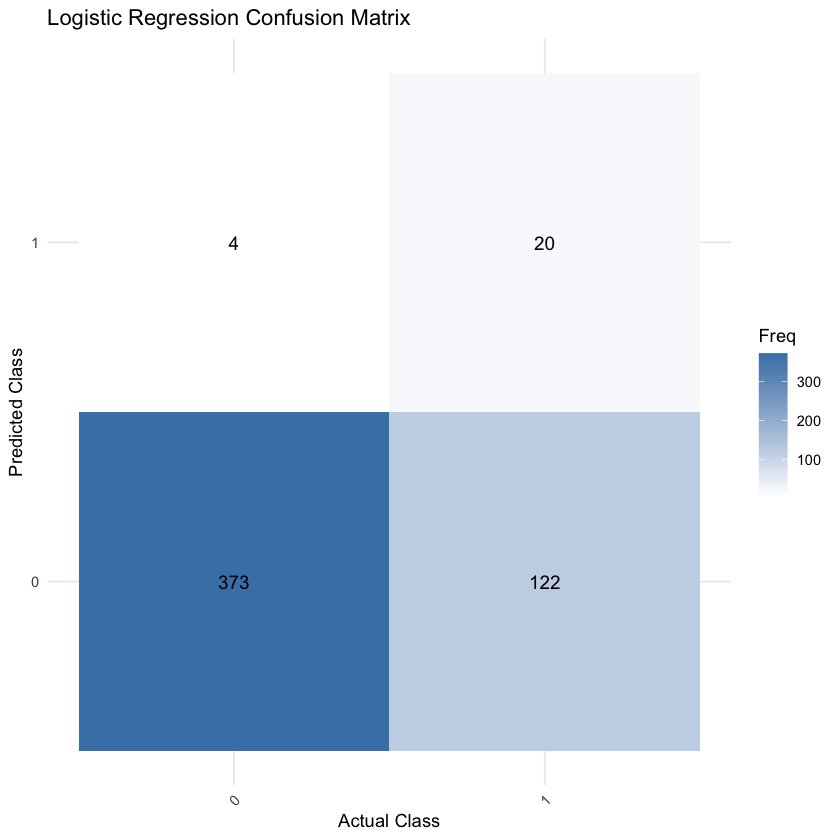

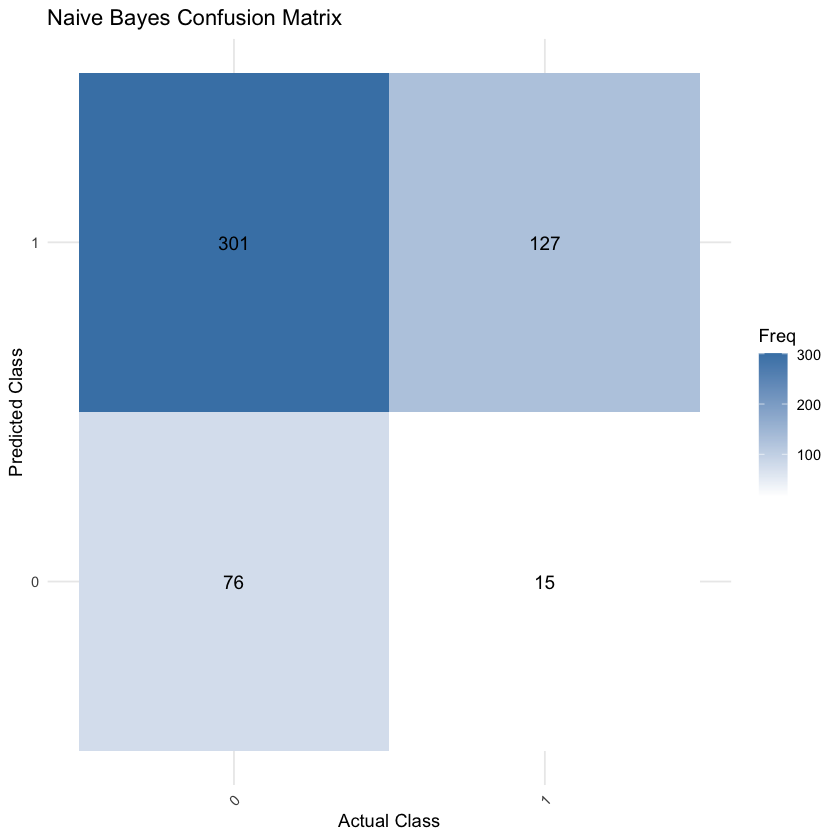

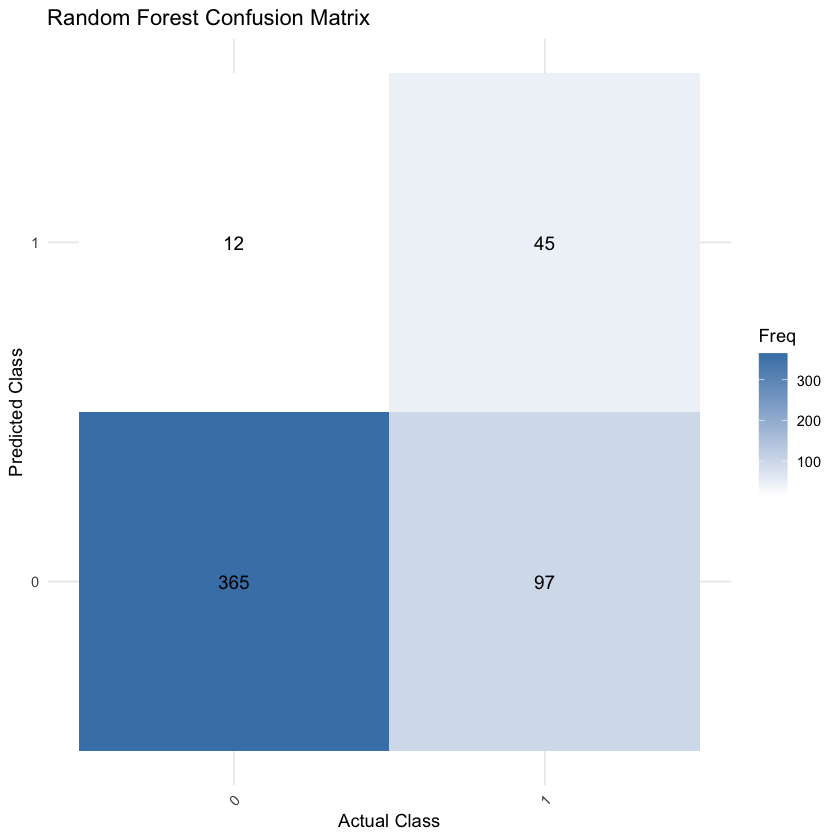

In [30]:
# Visualize confusion matrices
library(ggplot2)

# Function to create confusion matrix plot
plot_confusion_matrix <- function(cm, title) {
  cm_df <- as.data.frame(cm$table)
  
  ggplot(cm_df, aes(x = Reference, y = Prediction, fill = Freq)) +
    geom_tile() +
    geom_text(aes(label = Freq), color = "black", size = 4) +
    scale_fill_gradient(low = "white", high = "steelblue") +
    labs(title = title,
         x = "Actual Class",
         y = "Predicted Class") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

# Plot confusion matrices
plot_confusion_matrix(lasso_cm, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(nb_cm, "Naive Bayes Confusion Matrix")
plot_confusion_matrix(rf_cm, "Random Forest Confusion Matrix")





### Model Performance Comparison

Let's compare the key performance metrics between our three models.


                Model  Accuracy Balanced_Accuracy
1 Logistic Regression 0.7572254         0.5651175
2         Naive Bayes 0.3911368         0.5479789
3       Random Forest 0.7899807         0.6425356


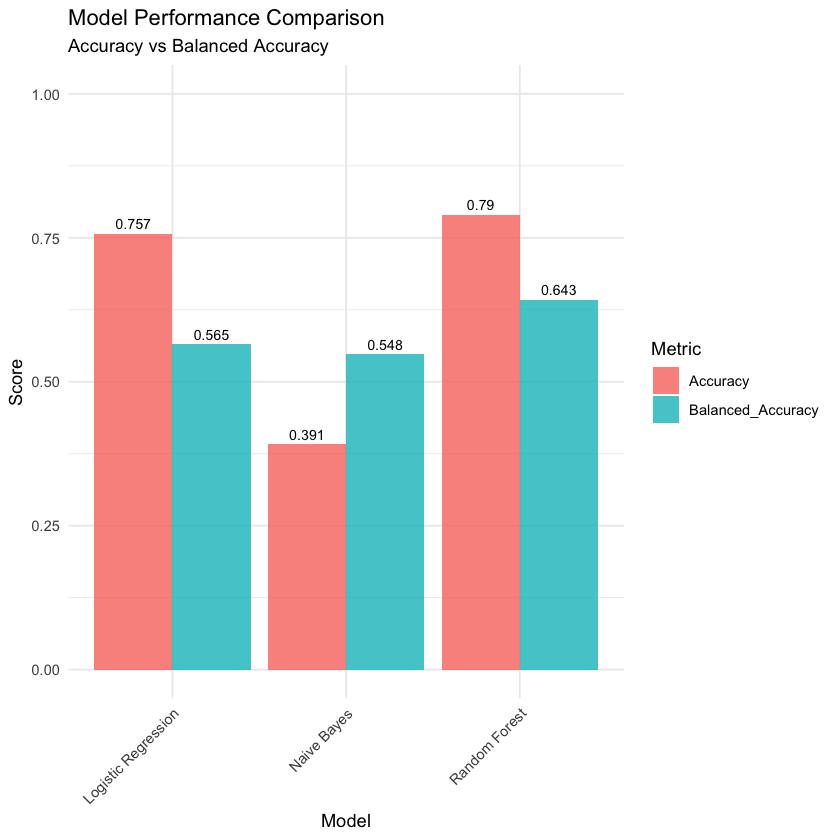

In [31]:
# Extract performance metrics from confusion matrices
performance_metrics <- data.frame(
  Model = c("Logistic Regression", "Naive Bayes", "Random Forest"),
  Accuracy = c(lasso_cm$overall["Accuracy"],
               nb_cm$overall["Accuracy"], 
               rf_cm$overall["Accuracy"]),
  Balanced_Accuracy = c(lasso_cm$byClass["Balanced Accuracy"],
                        nb_cm$byClass["Balanced Accuracy"],
                        rf_cm$byClass["Balanced Accuracy"])
)

# Display performance metrics
print(performance_metrics)

# Reshape data for plotting
performance_long <- performance_metrics %>%
  pivot_longer(cols = c(Accuracy, Balanced_Accuracy),
               names_to = "Metric", 
               values_to = "Score")

# Plot performance comparison
performance_long %>%
  ggplot(aes(x = Model, y = Score, fill = Metric)) +
  geom_col(position = "dodge", alpha = 0.8) +
  geom_text(aes(label = round(Score, 3)), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5, size = 3) +
  labs(title = "Model Performance Comparison",
       subtitle = "Accuracy vs Balanced Accuracy",
       x = "Model",
       y = "Score") +
  ylim(0, 1) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


## Exercise: Compare Bag-of-Words vs TF-IDF

Now it's your turn to experiment! Try training the same models using bag-of-words features instead of TF-IDF and compare the performance.


In [0]:
# Exercise: Train models with bag-of-words features
# Do you expect this to be much different from the TF-IDF analysis?
# YOUR CODE HERE

# Hint: Use the train_features_bow and test_features_bow we created earlier
# 1. Prepare the bag-of-words feature matrices
# 2. Train logistic regression and naive bayes models
# 3. Make predictions and evaluate performance
# 4. Compare with TF-IDF results

# Example structure:
# train_ml_bow <- train_data %>%
#   select(document_id, label) %>%
#   inner_join(train_features_bow, by = "document_id") %>%
#   select(-document_id)
# 
# # Train models...
# # Evaluate performance...
# # Compare results...


## Summary

In this lesson, we've covered the complete machine learning pipeline for text classification:

1. **Data Preparation**: We loaded and cleaned environmental text data, split it into training and test sets while maintaining class balance

2. **Feature Extraction**: We implemented both bag-of-words and TF-IDF approaches to convert text into numerical features suitable for machine learning

3. **Model Training**: We fitted two different classification algorithms:
   - **Logistic Regression**: A linear classifier with regularization
   - **Naïve Bayes**: A probabilistic classifier assuming feature independence
   - **Random Forest** A common purpose machine learning approach

4. **Model Evaluation**: We used multiple evaluation metrics:
   - **Confusion Matrices**: To understand classification errors
   - **Accuracy, Balanced Accuracy**: To measure overall and class-specific performance

### Key Insights:
- **TF-IDF vs Bag-of-Words**: TF-IDF often performs better by weighting rare but informative words more heavily
- **Model Comparison**: Different algorithms have different strengths - logistic regression provides interpretable coefficients, while naïve Bayes handles high-dimensional sparse data well
- **Feature Engineering**: Proper text preprocessing and vocabulary selection significantly impact model performance
- **Evaluation**: Multiple metrics provide a comprehensive view of model performance

These techniques form the foundation for more advanced NLP applications in environmental science and policy research.
